# Notebook de Análise de Dados Completo

Este notebook demonstra como usar Jupyter com as principais bibliotecas de ciência de dados: numpy, pandas, matplotlib e scikit-learn.

## 1. Importando as Bibliotecas

In [1]:
print("Hello, World")

Hello, World


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Configurações de visualização
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('✓ Todas as bibliotecas foram importadas com sucesso!')

✓ Todas as bibliotecas foram importadas com sucesso!


## 2. Carregando e Explorando Dados

In [3]:
# Carregando o dataset Iris
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['target_name'] = df['target'].map({0: 'Setosa', 1: 'Versicolor', 2: 'Virginica'})

print(f"Forma do dataset: {df.shape}")
print(f"\nPrimeiras linhas:")
print(df.head())
print(f"\nInfo do dataset:")
print(df.info())

Forma do dataset: (150, 6)

Primeiras linhas:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target target_name  
0       0      Setosa  
1       0      Setosa  
2       0      Setosa  
3       0      Setosa  
4       0      Setosa  

Info do dataset:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-

## 3. Análise Estatística

In [4]:
print("Estatísticas descritivas:")
print(df.describe())
print(f"\nContagem de classes:")
print(df['target_name'].value_counts())

Estatísticas descritivas:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  

Contagem de classes:
target_name
Setosa      

## 4. Visualização de Dados

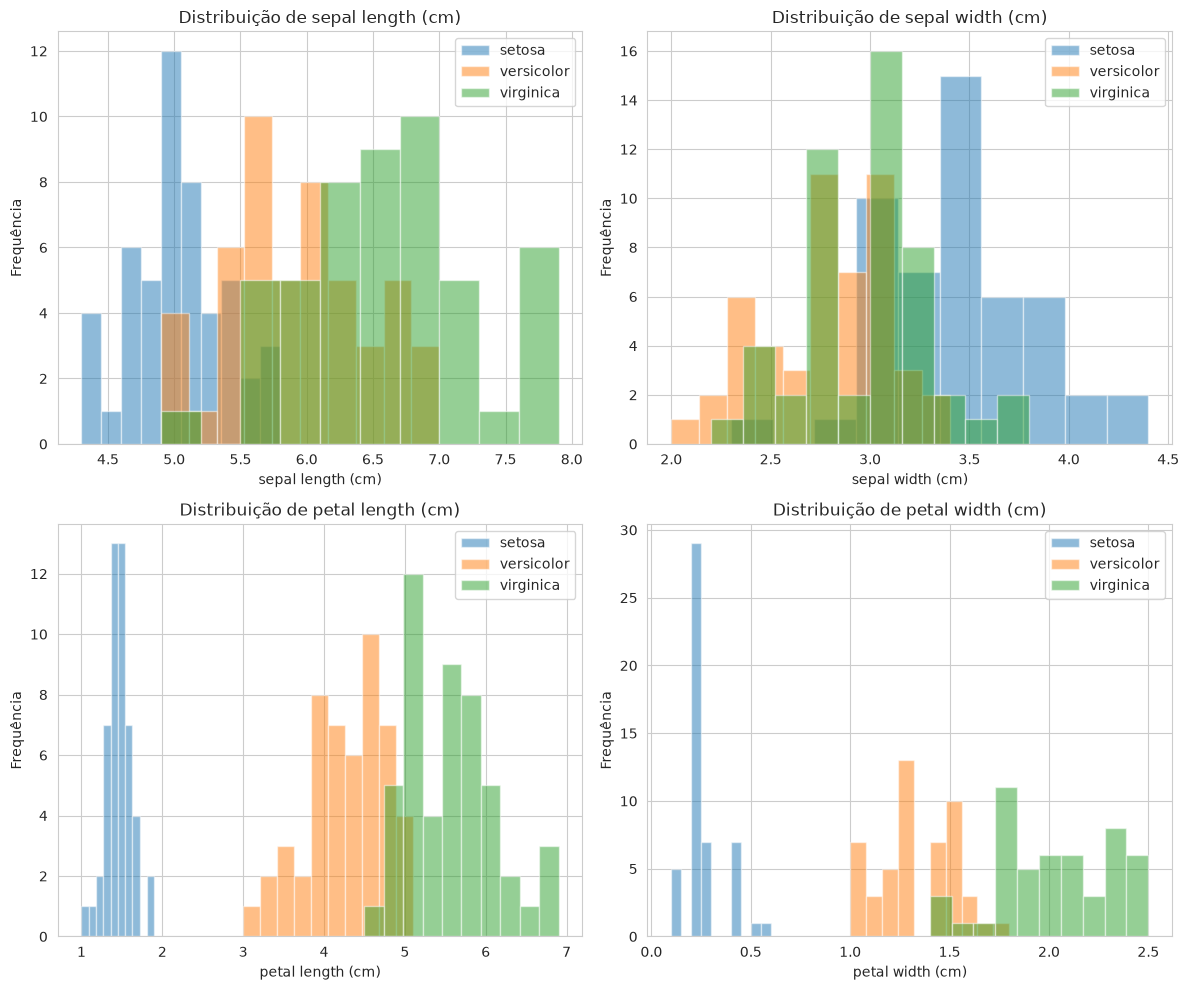

✓ Gráficos gerados com sucesso!


In [5]:
# Gráfico de distribuição
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
features = iris.feature_names

for idx, ax in enumerate(axes.flat):
    for target in [0, 1, 2]:
        ax.hist(df[df['target'] == target][features[idx]], alpha=0.5, label=iris.target_names[target])
    ax.set_xlabel(features[idx])
    ax.set_ylabel('Frequência')
    ax.set_title(f'Distribuição de {features[idx]}')
    ax.legend()

plt.tight_layout()
plt.show()

print('✓ Gráficos gerados com sucesso!')

## 5. Modelagem com Machine Learning

In [ ]:
# Preparando os dados
X = df.drop(['target', 'target_name'], axis=1)
y = df['target']

# Dividindo em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizando os dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Dados de treino: {X_train_scaled.shape}")
print(f"Dados de teste: {X_test_scaled.shape}")

In [ ]:
# Treinando o modelo
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Fazendo predições
y_pred = model.predict(X_test_scaled)

# Avaliando o modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {accuracy:.2%}")
print(f"\nRelatório de classificação:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

## 6. Importância das Features

In [ ]:
# Importância das features
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Importância das Features no Modelo')
plt.xlabel('Importância')
plt.show()

print(feature_importance)

## 7. Conclusão

Este notebook demonstrou:
- ✓ Carregamento e exploração de dados com Pandas
- ✓ Visualização com Matplotlib e Seaborn
- ✓ Processamento numérico com NumPy
- ✓ Machine Learning com Scikit-learn

Seu ambiente Jupyter está totalmente funcional!